In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import moduls.data_loader as data_loader
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import LabelEncoder

In [2]:
df = data_loader.load_data_csv("../data/for_clustering/Mall_Customers.csv")
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# Кодируем Gender
# df['Gender_Code'] = LabelEncoder().fit_transform(df['Genre'])

In [4]:
# 2. Предобработка
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] #'Gender_Code', 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

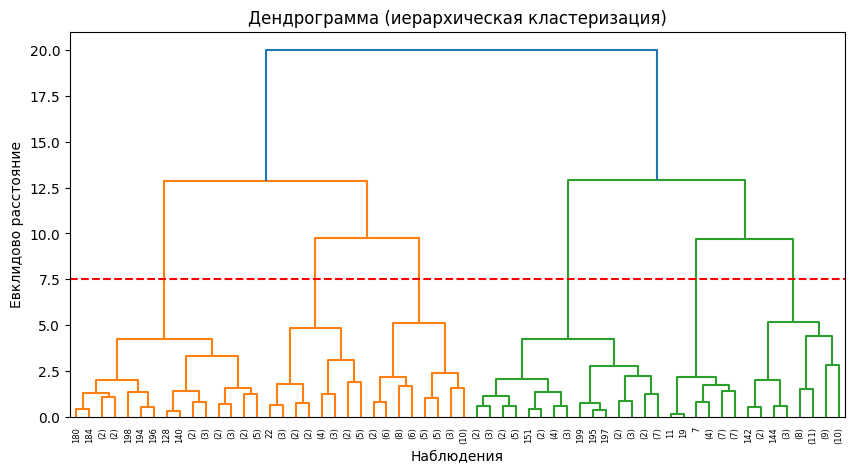

In [5]:
# 3. Иерархическая кластеризация
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.axhline(y=7.5, color='r', linestyle='--', label='Уровень среза (y=10)')
plt.title("Дендрограмма (иерархическая кластеризация)")
plt.xlabel("Наблюдения")
plt.ylabel("Евклидово расстояние")
plt.show()

In [6]:
# Оптимальное количество кластеров (например, по дендрограмме — 5)
agg = AgglomerativeClustering(n_clusters=6)
labels_agg = agg.fit_predict(X_scaled)
df['Cluster_Agg'] = labels_agg

In [7]:
for eps in [0.3, 0.5, 0.8, 1.0, 1.2]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    print(f"eps={eps} → кластеры: {set(labels)}, counts:", np.bincount(labels[labels >= 0]))

eps=0.3 → кластеры: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(-1)}, counts: [ 6  6  6 10  4  7  8  5  8  6]
eps=0.5 → кластеры: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(-1)}, counts: [17  5 51 28 32  7]
eps=0.8 → кластеры: {np.int64(0), np.int64(-1)}, counts: [194]
eps=1.0 → кластеры: {np.int64(0), np.int64(-1)}, counts: [198]
eps=1.2 → кластеры: {np.int64(0)}, counts: [200]


In [8]:
# 4. DBSCAN
db = DBSCAN(eps=0.5, min_samples=6)
labels_db = db.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = labels_db

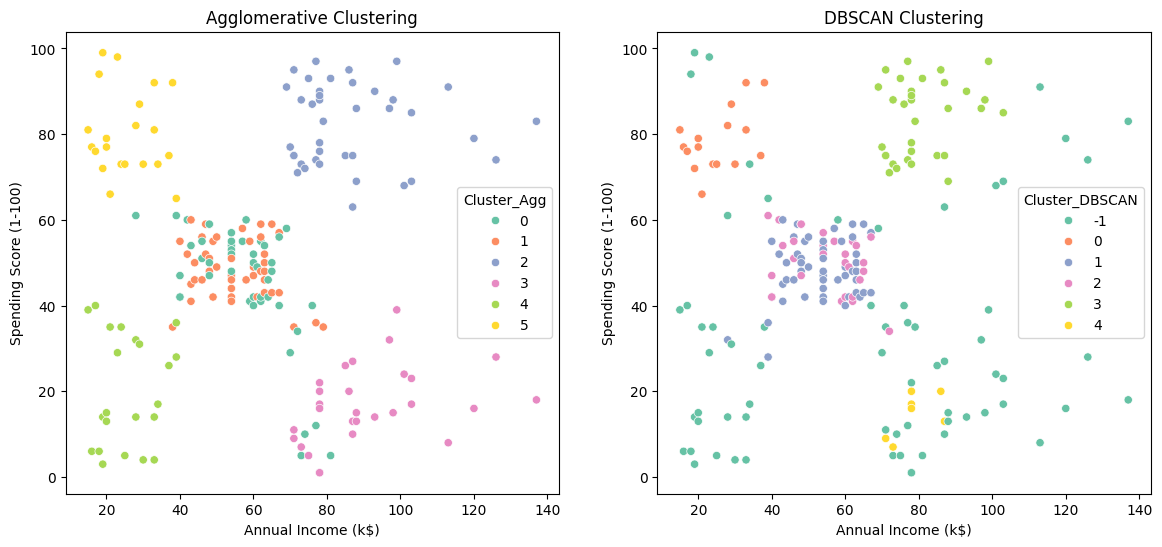

In [9]:
# 5. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(ax=axes[0],
                x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster_Agg', palette='Set2', data=df)
axes[0].set_title("Agglomerative Clustering")

sns.scatterplot(ax=axes[1],
                x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster_DBSCAN', palette='Set2', data=df)
axes[1].set_title("DBSCAN Clustering")

plt.show()

In [10]:
# 6. Сравнение результатов
print("Agglomerative кластеризация:")
print(df['Cluster_Agg'].value_counts())
print("\nDBSCAN:")
print(df['Cluster_DBSCAN'].value_counts())

Agglomerative кластеризация:
Cluster_Agg
0    45
1    45
2    39
3    28
4    22
5    21
Name: count, dtype: int64

DBSCAN:
Cluster_DBSCAN
-1    66
 1    50
 3    32
 2    29
 0    16
 4     7
Name: count, dtype: int64
